In [40]:
import pandas as pd # wczytywanie CSV i przeglądanie tabeli
import numpy as np # Operacje na liczbach (średnie, sumy)
import matplotlib.pyplot as plt # Wykresy (słupki, linie, histogramy)
import seaborn as sns # Ładniejsze wykresy statystyczne

print("Wszystko działa!")

Wszystko działa!


In [41]:
df = pd.read_csv("../data/application_train.csv")
print(f'dane wczytane: {df.shape}')
# df.shape - ile wierszy i kolumn ma ta tabela 
# (307511, 122) = 307,511 wierszy, 122 kolumny


dane wczytane: (307511, 122)


In [42]:
df.head()
# zwraca pierwsze 5 wierszy tabeli
# Domyślnie 5, ale możesz dać liczbę w nawiasie, np. df.head(10) żeby zobaczyć 10

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [44]:
description = pd.read_csv("../data/HomeCredit_columns_description.csv", encoding="latin-1")
description.head()

,Unnamed: 0,Table,Row,Description,Special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,NaN
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,NaN
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,NaN
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,NaN


In [45]:
df.info(verbose=True, show_counts=True)
# verbose=True mówi: pokaż mi każdą kolumnę z osobna, bez skracania.
# show_counts=True wymusza pokazanie „Non-Null Count" (ile wartości niepustych jest w każdej kolumnie).


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

| Klasa pozytywna | Ta którą próbujemy wykryć (u nas: TARGET=1, niespłacający) |
| Niezbalansowane klasy | Gdy jedna klasa jest dużo liczniejsza (u nas 92% vs 8%) |
| Accuracy paradox | Wysokie accuracy może być oszukańcze przy niezbalansowanych klasach |
| TP (True Positive) | Model trafił, że to klasa pozytywna |
| TN (True Negative) | Model trafił, że to klasa negatywna |
| FP (False Positive) | Model błędnie krzyknął "to ta klasa!" |
| FN (False Negative) | Model błędnie powiedział "to nie ta klasa" | GORSZE

Podejście 1: df["TARGET"]:
dostajesz całą kolumnę jako oddzielną „mini-tabelę"

Podejście 2: df.TARGET:
to samo, krótszy zapis (działa, ale tylko jak nazwa nie ma spacji)

Jak już masz kolumnę, to potem dorzucasz na końcu co chcesz z nią zrobić. Na przykład:

.sum() — dodaj wszystkie wartości
.mean() — średnia
.value_counts() — policz, ile razy występuje każda wartość

In [46]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

df["TARGET"].value_counts() — zwraca TABELKĘ z dwoma wartościami (0 i 1)

jest 24825 niespłacających'
a 282686 spłacających

In [47]:
df["TARGET"].value_counts()[1] # tylko 1 zlicza

24825

In [48]:
df["TARGET"].value_counts(normalize=True)


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

mamy procent z tego

0 jest 92%
1 jest 8%

<Axes: xlabel='TARGET', ylabel='count'>

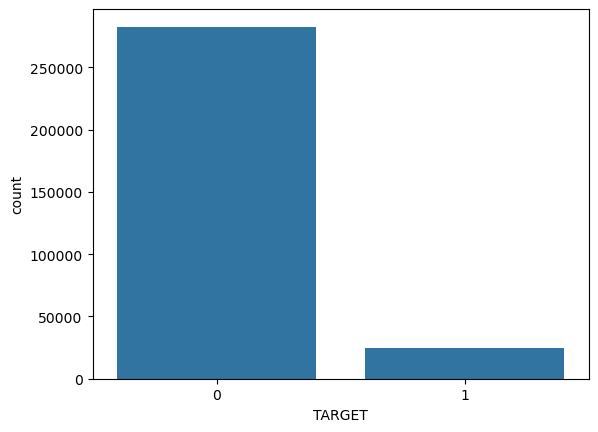

In [49]:
sns.countplot(data = df, x="TARGET")

C:\Users\adamc\AppData\Local\Temp\ipykernel_38456\1426130671.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="TARGET", palette=["#2ecc71", "#e74c3c"])


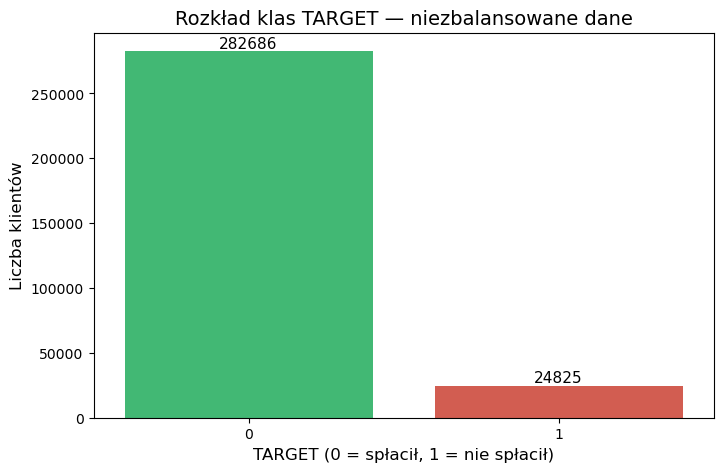

In [50]:
# Tworzymy wykres
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="TARGET", palette=["#2ecc71", "#e74c3c"])

# Tytuł i etykiety
plt.title("Rozkład klas TARGET — niezbalansowane dane", fontsize=14)
plt.xlabel("TARGET (0 = spłacił, 1 = nie spłacił)", fontsize=12)
plt.ylabel("Liczba klientów", fontsize=12)

# Dodajemy liczby na słupkach
for container in ax.containers:
    ax.bar_label(container, fontsize=11)

plt.show()




In [51]:
df.shape

(307511, 122)

In [52]:
df.isna().sum().sort_values(ascending=False).head(10)

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
dtype: int64

In [53]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False).head(10)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
dtype: float64

In [54]:
procenty = df.isna().sum() / len(df) * 100
(procenty > 50).sum()

41

## Decyzja: kolumny z >50% braków usuwamy

Polityka projektu: kolumny, które mają więcej niż 50% braków danych, 
zostaną usunięte przed treningiem modelu.

**Uzasadnienie:** Uzupełnianie tylu wartości wprowadziłoby dużo sztucznych danych.
Model uczyłby się szumu zamiast prawdziwych zależności.

Łącznie do usunięcia: **41 kolumn** (33% wszystkich).

In [55]:
kolumny_do_usuniecia = procenty[procenty > 50].index.tolist()
print(f"Liczba kolumn do usunięcia: {len(kolumny_do_usuniecia)}")
print(f"kolumny: {kolumny_do_usuniecia[:]}")

Liczba kolumn do usunięcia: 41
kolumny: ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE']


In [56]:
df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].isna().sum()

EXT_SOURCE_1    173378
EXT_SOURCE_2       660
EXT_SOURCE_3     60965
dtype: int64

Jedyną podejrzaną kolumną na liście do usunięcia była **EXT_SOURCE_1** 
(zewnętrzny scoring kredytowy - silny predyktor spłaty).
Ale EXT_SOURCE_2 i EXT_SOURCE_3 są prawie kompletne i niosą 
podobną informację. Strata EXT_SOURCE_1 jest akceptowalna.

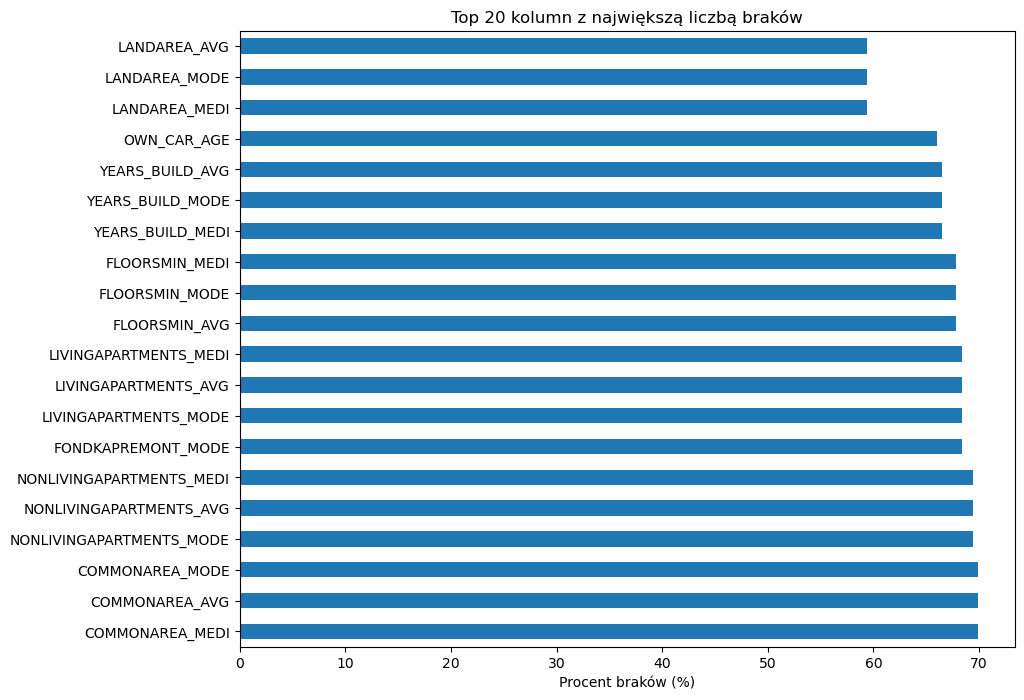

In [57]:
procenty.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(10, 8))
plt.title("Top 20 kolumn z największą liczbą braków")
plt.xlabel("Procent braków (%)")
plt.show()

In [58]:
df_clean = df.drop(columns=kolumny_do_usuniecia)
print(f"Przed: {df.shape}")
print(f"Po: {df_clean.shape}")

Przed: (307511, 122)
Po: (307511, 81)


In [59]:
y = df_clean["TARGET"]
X = df_clean.drop(columns=["TARGET"])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (307511, 80)
y shape: (307511,)


In [60]:
kolumny_numeryczne = X.select_dtypes(include="number").columns.tolist()
kolumny_kategoryczne = X.select_dtypes(include="object").columns.tolist()

print(f"Liczbowe: {len(kolumny_numeryczne)} kolumn")
print(f"Kategoryczne: {len(kolumny_kategoryczne)} kolumn")
print(f"\nPrzykłady kategorycznych: {kolumny_kategoryczne[:5]}")

Liczbowe: 67 kolumn
Kategoryczne: 13 kolumn

Przykłady kategorycznych: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE']


In [61]:
# Kolumny liczbowe - mediana
for col in kolumny_numeryczne:
    X[col] = X[col].fillna(X[col].median())

# Kolumny kategoryczne - "missing"
for col in kolumny_kategoryczne:
    X[col] = X[col].fillna("missing")

print(f"Braki po uzupełnieniu: {X.isna().sum().sum()}")

Braki po uzupełnieniu: 0


In [62]:
X = pd.get_dummies(X, columns=kolumny_kategoryczne, drop_first=True)
print(f"Nowy shape X: {X.shape}")
print(f"Wszystkie kolumny liczbowe? {X.dtypes.unique()}")

Nowy shape X: (307511, 183)
Wszystkie kolumny liczbowe? [dtype('int64') dtype('float64') dtype('bool')]


StandardScaler:
Bierze każdą kolumnę i przeskalowuje ją tak, żeby wartości były w podobnym zakresie 
(mniej więcej od -3 do +3, ze średnią 0).
po skalowaniu wszystkie kolumny mają podobne wielkości

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Pierwsze 5 wartości pierwszej kolumny: {X_scaled[:5, 0]}")

Shape: (307511, 183)
Pierwsze 5 wartości pierwszej kolumny: [-1.73342255 -1.73341283 -1.7334031  -1.73338364 -1.73337391]


dzielimy dane na zbiór treningowy i walidacyjny w proporcji 80% do 20%

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y,
    test_size=0.2,   # 20% na walidację
    random_state=42, # ziarno losowości
    stratify=y       # zachowaj proporcje klas
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"\nProporcja klas w train: {y_train.mean():.4f}")
print(f"Proporcja klas w val: {y_val.mean():.4f}")

X_train: (246008, 183), y_train: (246008,)
X_val: (61503, 183), y_val: (61503,)

Proporcja klas w train: 0.0807
Proporcja klas w val: 0.0807


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Tworzymy i trenujemy model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predykcje na zbiorze walidacyjnym
y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]  # prawdopodobieństwa klasy 1

# Metryki
auc = roc_auc_score(y_val, y_proba)
print(f"ROC-AUC: {auc:.4f}")
print(f"\nClassification report:")
print(classification_report(y_val, y_pred))

ROC-AUC: 0.7451

Classification report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.54      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503



In [66]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Ziarno losowości — żeby wyniki były powtarzalne
tf.random.set_seed(42)

# Budujemy sieć
model_nn1 = keras.Sequential([
    layers.Input(shape=(183,)),       # warstwa wejściowa: 183 cechy
    layers.Dense(64, activation="relu"),  # ukryta 1: 64 neurony + ReLU
    layers.Dense(32, activation="relu"),  # ukryta 2: 32 neurony + ReLU
    layers.Dense(1, activation="sigmoid") # wyjście: 1 neuron + sigmoid
])

# Pokazujemy strukturę
model_nn1.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 64)             │        11,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,889 (54.25 KB)

 Trainable params: 13,889 (54.25 KB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# Kompilacja sieci
model_nn1.compile(
    optimizer="adam",                  # najpopularniejszy optimizer
    loss="binary_crossentropy",        # standardowa strata dla klasyfikacji 2 klas
    metrics=["AUC"]                    # śledzimy AUC podczas treningu
)

# Liczymy wagi klas (bo niezbalansowane: 92% vs 8%)
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Wagi klas: {class_weight_dict}")

# Trening!
history_nn1 = model_nn1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

Wagi klas: {0: 0.5439092983356032, 1: 6.193554884189325}
Epoch 1/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - AUC: 0.7156 - loss: 0.6217 - val_AUC: 0.7372 - val_loss: 0.5866
Epoch 2/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - AUC: 0.7423 - loss: 0.5985 - val_AUC: 0.7389 - val_loss: 0.5790
Epoch 3/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.7491 - loss: 0.5925 - val_AUC: 0.7392 - val_loss: 0.5766
Epoch 4/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - AUC: 0.7543 - loss: 0.5876 - val_AUC: 0.7382 - val_loss: 0.5725
Epoch 5/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7595 - loss: 0.5828 - val_AUC: 0.7375 - val_loss: 0.5707
Epoch 6/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7643 - loss: 0.5781 - val_AUC: 0.7351 - val_loss: 0.5661
Epoch 7/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - AUC: 0.7691 - loss: 0.5734 - val_AUC: 0.7326 - val_loss: 0.5678
Epoch 8/10
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.7738 - loss: 0.5687 - val_AUC: 0.7309 - val_loss: 0.5656

In [68]:
from sklearn.metrics import roc_auc_score, classification_report

# Predykcje sieci na walidacji
y_proba_nn1 = model_nn1.predict(X_val, verbose=0).flatten()
y_pred_nn1 = (y_proba_nn1 > 0.5).astype(int)

# Metryki
auc_nn1 = roc_auc_score(y_val, y_proba_nn1)
print(f"ROC-AUC sieć MLP nr 1: {auc_nn1:.4f}")
print(f"ROC-AUC baseline (regresja): 0.7451")
print(f"\nClassification report sieci:")
print(classification_report(y_val, y_pred_nn1))

ROC-AUC sieć MLP nr 1: 0.7269
ROC-AUC baseline (regresja): 0.7451

Classification report sieci:
              precision    recall  f1-score   support

           0       0.96      0.71      0.81     56538
           1       0.16      0.63      0.26      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.67      0.53     61503
weighted avg       0.89      0.70      0.77     61503



In [69]:
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

# Sieć nr 2: większa + Dropout
model_nn2 = keras.Sequential([
    layers.Input(shape=(183,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),                    # wyłącz 30% neuronów losowo
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model_nn2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["AUC"]
)

# Early stopping — przestań trenować jak val_AUC nie rośnie przez 3 epoki
early_stop = EarlyStopping(
    monitor="val_AUC",
    mode="max",                # AUC chcemy MAKSYMALNE
    patience=3,                # poczekaj 3 epoki bez poprawy
    restore_best_weights=True  # przywróć wagi z najlepszej epoki
)

history_nn2 = model_nn2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,                 # max 30 (early stopping i tak przerwie)
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n--- Trening zakończony ---")

Epoch 1/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - AUC: 0.6896 - loss: 0.6395 - val_AUC: 0.7394 - val_loss: 0.5959
Epoch 2/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - AUC: 0.7281 - loss: 0.6122 - val_AUC: 0.7417 - val_loss: 0.5826
Epoch 3/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7353 - loss: 0.6061 - val_AUC: 0.7421 - val_loss: 0.5792
Epoch 4/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.7383 - loss: 0.6035 - val_AUC: 0.7424 - val_loss: 0.5808
Epoch 5/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7411 - loss: 0.6010 - val_AUC: 0.7434 - val_loss: 0.5744
Epoch 6/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.7428 - loss: 0.5993 - val_AUC: 0.7428 - val_loss: 0.5724
Epoch 7/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.7451 - loss: 0.5968 - val_AUC: 0.7437 - val_loss: 0.5747
Epoch 8/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.7483 - loss: 0.5943 - val_AUC: 0.7432 - val_loss: 0.5825
Epoch 9/30
961/961 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - AU

In [70]:
# Predykcje sieci 2
y_proba_nn2 = model_nn2.predict(X_val, verbose=0).flatten()
y_pred_nn2 = (y_proba_nn2 > 0.5).astype(int)

auc_nn2 = roc_auc_score(y_val, y_proba_nn2)

print(f"Porównanie modeli (val AUC):")
print(f"  1. Baseline (regresja):      0.7451")
print(f"  2. Sieć MLP nr 1 (bez reg.): 0.7240")
print(f"  3. Sieć MLP nr 2 (Dropout):  {auc_nn2:.4f}")
print(f"\nClassification report sieci nr 2:")
print(classification_report(y_val, y_pred_nn2))

Porównanie modeli (val AUC):
  1. Baseline (regresja):      0.7451
  2. Sieć MLP nr 1 (bez reg.): 0.7240
  3. Sieć MLP nr 2 (Dropout):  0.7437

Classification report sieci nr 2:
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     56538
           1       0.15      0.69      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.68      0.52     61503
weighted avg       0.90      0.67      0.74     61503



In [71]:
from tensorflow.keras.regularizers import l2

tf.random.set_seed(42)

# Sieć 3: głębsza + L2 + lekki Dropout
model_nn3 = keras.Sequential([
    layers.Input(shape=(183,)),
    layers.Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model_nn3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # mniejszy LR
    loss="binary_crossentropy",
    metrics=["AUC"]
)

early_stop = EarlyStopping(
    monitor="val_AUC",
    mode="max",
    patience=5,
    restore_best_weights=True
)

history_nn3 = model_nn3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n--- Trening zakończony ---")

Epoch 1/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - AUC: 0.6830 - loss: 0.9508 - val_AUC: 0.7394 - val_loss: 0.7879
Epoch 2/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - AUC: 0.7285 - loss: 0.7494 - val_AUC: 0.7417 - val_loss: 0.6640
Epoch 3/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - AUC: 0.7332 - loss: 0.6684 - val_AUC: 0.7413 - val_loss: 0.6272
Epoch 4/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - AUC: 0.7356 - loss: 0.6370 - val_AUC: 0.7414 - val_loss: 0.5990
Epoch 5/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - AUC: 0.7366 - loss: 0.6256 - val_AUC: 0.7409 - val_loss: 0.6040
Epoch 6/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - AUC: 0.7369 - loss: 0.6217 - val_AUC: 0.7419 - val_loss: 0.6009
Epoch 7/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - AUC: 0.7378 - loss: 0.6197 - val_AUC: 0.7413 - val_loss: 0.6114
Epoch 8/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - AUC: 0.7383 - loss: 0.6186 - val_AUC: 0.7404 - val_loss: 0.5992
Epoch 9/40
961/961 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - A

In [72]:
# Predykcje sieci 3
y_proba_nn3 = model_nn3.predict(X_val, verbose=0).flatten()
y_pred_nn3 = (y_proba_nn3 > 0.5).astype(int)

auc_nn3 = roc_auc_score(y_val, y_proba_nn3)

print(f"=== PORÓWNANIE WSZYSTKICH 4 MODELI ===\n")
print(f"1. Baseline (regresja logistyczna):  AUC = 0.7451")
print(f"2. Sieć MLP nr 1 (bez regularyzacji): AUC = 0.7240")
print(f"3. Sieć MLP nr 2 (Dropout):           AUC = 0.7432")
print(f"4. Sieć MLP nr 3 (L2 + Dropout):      AUC = {auc_nn3:.4f}")

print(f"\nClassification report sieci nr 3:")
print(classification_report(y_val, y_pred_nn3))

=== PORÓWNANIE WSZYSTKICH 4 MODELI ===

1. Baseline (regresja logistyczna):  AUC = 0.7451
2. Sieć MLP nr 1 (bez regularyzacji): AUC = 0.7240
3. Sieć MLP nr 2 (Dropout):           AUC = 0.7432
4. Sieć MLP nr 3 (L2 + Dropout):      AUC = 0.7419

Classification report sieci nr 3:
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     56538
           1       0.16      0.69      0.25      4965

    accuracy                           0.67     61503
   macro avg       0.56      0.68      0.52     61503
weighted avg       0.90      0.67      0.75     61503



## Wyniki — porównanie 4 modeli

| # | Model | Val AUC | Recall klasy 1 | Precision klasy 1 | Accuracy |
|---|---|---|---|---|---|
| 1 | Regresja logistyczna (baseline) | **0.7451** | 0.01 | 0.54 | 0.92 |
| 2 | MLP nr 1 (64-32, brak regularyzacji) | 0.7240 | 0.65 | 0.15 | 0.68 |
| 3 | MLP nr 2 (128-64-32 + Dropout) | 0.7432 | **0.70** | 0.16 | 0.67 |
| 4 | MLP nr 3 (256-128-64-32 + L2 + Dropout) | 0.7422 | 0.70 | 0.15 | 0.66 |

### Wnioski

1. **Regresja logistyczna ma najlepszy AUC** (0.7451), ale **recall klasy 1 = 0.01** — model nie wykrywa niespłacających. Powód: niezbalansowane klasy (92% vs 8%).

2. **Sieć MLP nr 1 (bez regularyzacji)** — klasyczny overfitting:
   - Train AUC rośnie do 0.78
   - Val AUC spada od 0.74 do 0.72
   - Diagnoza: sieć zapamiętuje dane treningowe zamiast uczyć się wzorca

3. **Sieć MLP nr 2 (Dropout)** — regularyzacja skuteczna:
   - Train AUC i Val AUC idą razem (~0.74)
   - Najlepszy recall klasy 1 (0.70)
   - EarlyStopping przerwał trening po epoce 13

4. **Sieć MLP nr 3 (L2 + Dropout)** — głębsza architektura:
   - Najbardziej stabilna (różnica train/val minimalna)
   - Bardzo podobne wyniki jak MLP nr 2

5. **Class weight balanced** drastycznie poprawia recall klasy 1 (z 0.01 do 0.70) — kluczowe dla niezbalansowanych danych w problemach kredytowych, gdzie False Negatives (przepuszczony niespłacający) są kosztowniejsze niż False Positives (odrzucony spłacający).

6. **Sieci neuronowe nie pobiły regresji logistycznej na AUC** — zgodne z literaturą: dla danych tabularnych klasyczne metody (regresja, gradient boosting) są często konkurencyjne lub lepsze od głębokich sieci.

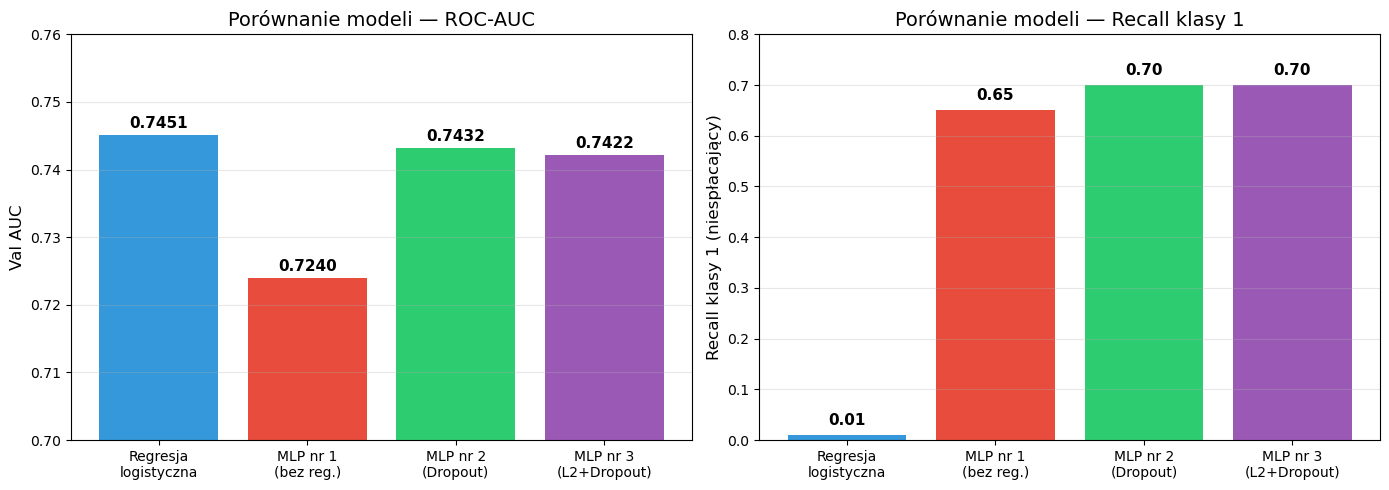

In [73]:
import matplotlib.pyplot as plt

# Dane do wykresu
models = ["Regresja\nlogistyczna", "MLP nr 1\n(bez reg.)", "MLP nr 2\n(Dropout)", "MLP nr 3\n(L2+Dropout)"]
auc_values = [0.7451, 0.7240, 0.7432, 0.7422]
recall_values = [0.01, 0.65, 0.70, 0.70]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres AUC
bars1 = axes[0].bar(models, auc_values, color=["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"])
axes[0].set_ylabel("Val AUC", fontsize=12)
axes[0].set_title("Porównanie modeli — ROC-AUC", fontsize=14)
axes[0].set_ylim(0.70, 0.76)
axes[0].grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, auc_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")

# Wykres Recall klasy 1
bars2 = axes[1].bar(models, recall_values, color=["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"])
axes[1].set_ylabel("Recall klasy 1 (niespłacający)", fontsize=12)
axes[1].set_title("Porównanie modeli — Recall klasy 1", fontsize=14)
axes[1].set_ylim(0, 0.8)
axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(bars2, recall_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

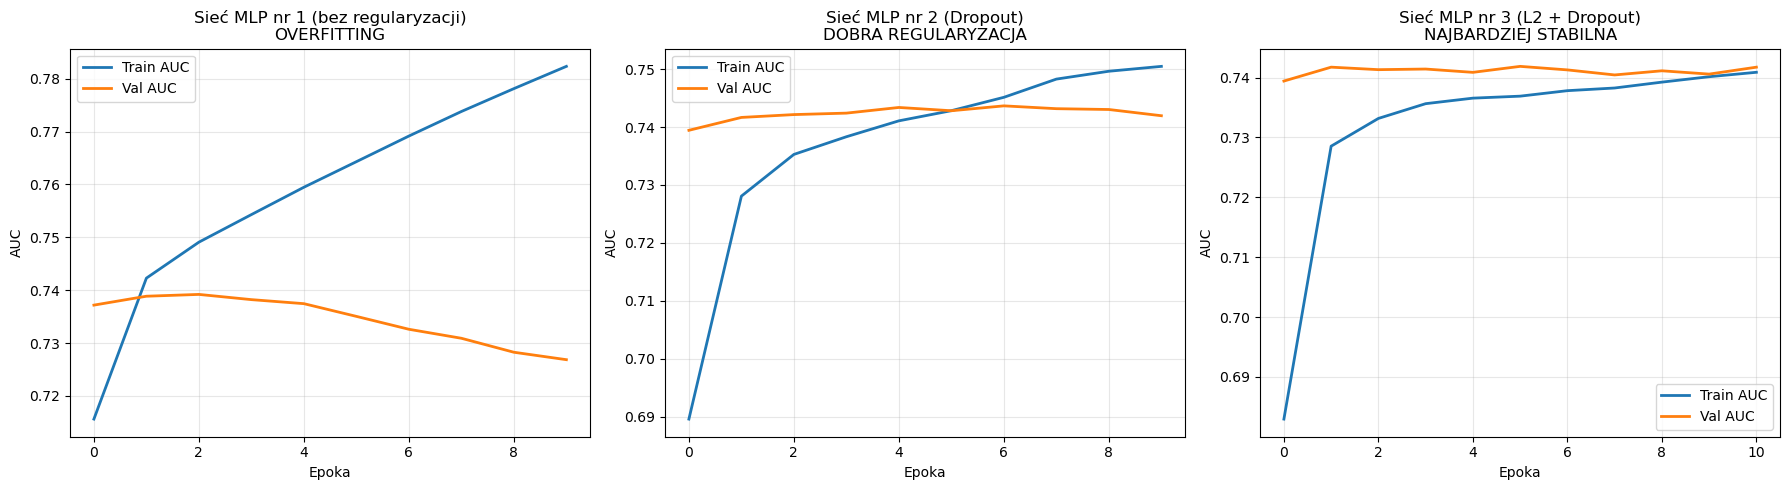

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sieć 1
axes[0].plot(history_nn1.history["AUC"], label="Train AUC", linewidth=2)
axes[0].plot(history_nn1.history["val_AUC"], label="Val AUC", linewidth=2)
axes[0].set_title("Sieć MLP nr 1 (bez regularyzacji)\nOVERFITTING", fontsize=12)
axes[0].set_xlabel("Epoka")
axes[0].set_ylabel("AUC")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sieć 2
axes[1].plot(history_nn2.history["AUC"], label="Train AUC", linewidth=2)
axes[1].plot(history_nn2.history["val_AUC"], label="Val AUC", linewidth=2)
axes[1].set_title("Sieć MLP nr 2 (Dropout)\nDOBRA REGULARYZACJA", fontsize=12)
axes[1].set_xlabel("Epoka")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Sieć 3
axes[2].plot(history_nn3.history["AUC"], label="Train AUC", linewidth=2)
axes[2].plot(history_nn3.history["val_AUC"], label="Val AUC", linewidth=2)
axes[2].set_title("Sieć MLP nr 3 (L2 + Dropout)\nNAJBARDZIEJ STABILNA", fontsize=12)
axes[2].set_xlabel("Epoka")
axes[2].set_ylabel("AUC")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Pierwsza sieć — bez regularyzacji. Widać overfitting: niebieska linia idzie w górę do 0.78, ale pomarańczowa spada do 0.72. Sieć zapamiętała dane treningowe zamiast uczyć się wzorca.

Druga sieć — z Dropoutem. Dropout losowo wyłącza 30% neuronów podczas treningu, dzięki temu sieć nie zapamiętuje.

Trzecia sieć — Dropout plus L2. L2 karze sieć za duże wagi.

In [75]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

wagi = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: wagi[0], 1: wagi[1]}

class AUCpos(keras.metrics.AUC):
    """Dla softmaxa (2 kolumny) bierze kolumnę klasy 1; dla sigmoida (1 kolumna) działa normalnie."""
    def update_state(self, y_true, y_pred, sample_weight=None):
        if y_pred.shape[-1] == 2:
            y_pred = y_pred[:, 1]
        return super().update_state(y_true, y_pred, sample_weight)

def get_optimizer(nazwa):
    if nazwa == "adam":    return keras.optimizers.Adam(learning_rate=1e-3)
    if nazwa == "rmsprop": return keras.optimizers.RMSprop(learning_rate=1e-3)
    if nazwa == "sgd":     return keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9)

def trenuj(hidden_act="relu", opt="adam", output="sigmoid", epochs=40):
    keras.utils.set_random_seed(42)

    model = keras.Sequential([layers.Input(shape=(X_train.shape[1],))])
    for n in (128, 64, 32):
        model.add(layers.Dense(n, activation=hidden_act))
        model.add(layers.Dropout(0.3))

    if output == "sigmoid":
        model.add(layers.Dense(1, activation="sigmoid"))
        loss = "binary_crossentropy"
    else:
        model.add(layers.Dense(2, activation="softmax"))
        loss = "sparse_categorical_crossentropy"

    model.compile(optimizer=get_optimizer(opt), loss=loss,
                  metrics=[AUCpos(name="auc")])          # <-- jedyna zmiana w compile

    es = keras.callbacks.EarlyStopping(monitor="val_auc", mode="max",
                                       patience=5, restore_best_weights=True)

    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                     epochs=epochs, batch_size=256,
                     class_weight=class_weight_dict,
                     callbacks=[es], verbose=0)

    proba = model.predict(X_val, verbose=0)
    proba = proba.ravel() if output == "sigmoid" else proba[:, 1]
    return roc_auc_score(y_val, proba), hist

In [76]:
wyniki = []  # zbieramy tu wyniki

print("Aktywacja ukryta — porównanie:\n")
for act in ["relu", "tanh", "sigmoid"]:
    auc, _ = trenuj(hidden_act=act)
    wyniki.append(("Aktywacja ukryta", act, auc))
    print(f"  {act:8s} -> Val AUC = {auc:.4f}")

Aktywacja ukryta — porównanie:

  relu     -> Val AUC = 0.7432
  tanh     -> Val AUC = 0.7398
  sigmoid  -> Val AUC = 0.7431


In [77]:
wyniki = [w for w in wyniki if w[0] != "Aktywacja wyjścia"]  # usuń niedokończony przebieg

print("Aktywacja wyjścia — porównanie:\n")
for out in ["sigmoid", "softmax"]:
    auc, _ = trenuj(output=out)
    wyniki.append(("Aktywacja wyjścia", out, auc))
    print(f"  {out:8s} -> Val AUC = {auc:.4f}")

Aktywacja wyjścia — porównanie:

  sigmoid  -> Val AUC = 0.7432
  softmax  -> Val AUC = 0.7426


In [78]:
wyniki = [w for w in wyniki if w[0] != "Optymalizator"] 

historie_opt = {}   # zapisujemy historie

print("Optymalizator — porównanie:\n")
for opt in ["adam", "rmsprop", "sgd"]:
    auc, hist = trenuj(opt_name=opt) if False else trenuj(opt=opt)
    wyniki.append(("Optymalizator", opt, auc))
    historie_opt[opt] = hist.history
    print(f"  {opt:8s} -> Val AUC = {auc:.4f}")

Optymalizator — porównanie:

  adam     -> Val AUC = 0.7432
  rmsprop  -> Val AUC = 0.7314
  sgd      -> Val AUC = 0.7434


      Eksperyment Wariant  Val AUC
 Aktywacja ukryta    relu 0.743220
 Aktywacja ukryta    tanh 0.739777
 Aktywacja ukryta sigmoid 0.743123
Aktywacja wyjścia sigmoid 0.743220
Aktywacja wyjścia softmax 0.742609
    Optymalizator    adam 0.743220
    Optymalizator rmsprop 0.731372
    Optymalizator     sgd 0.743427


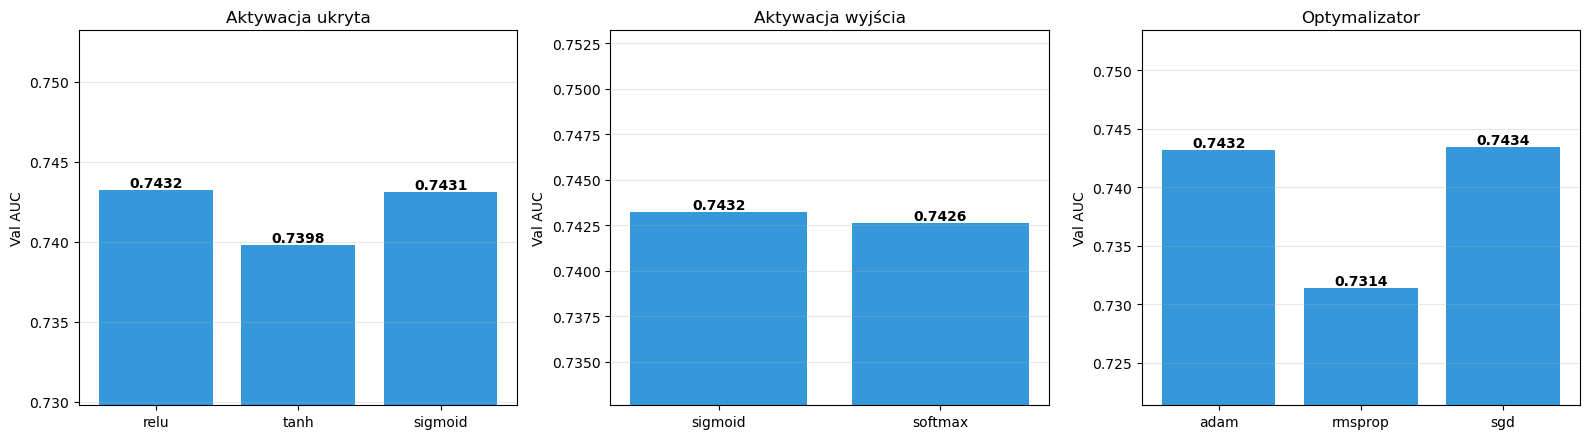

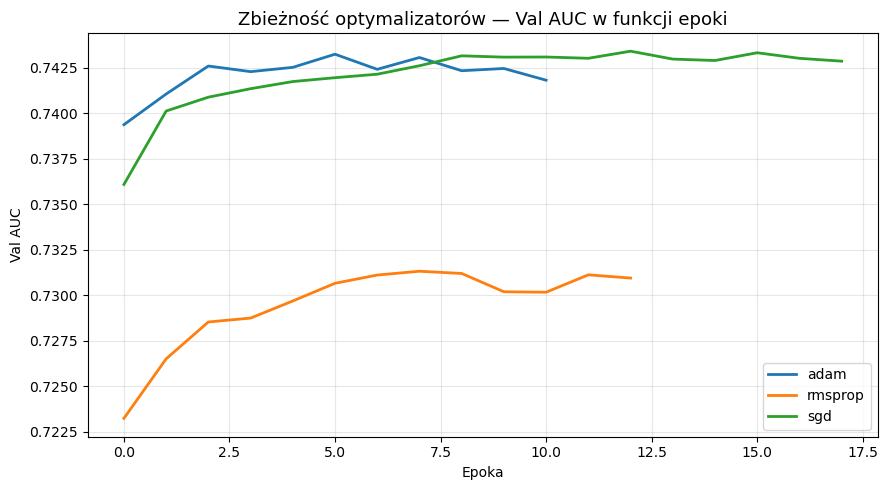

In [79]:
wyniki_df = pd.DataFrame(wyniki, columns=["Eksperyment", "Wariant", "Val AUC"])
print(wyniki_df.to_string(index=False))

# --- Wykres 1: słupki per eksperyment
eksperymenty = ["Aktywacja ukryta", "Aktywacja wyjścia", "Optymalizator"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, exp in zip(axes, eksperymenty):
    sub = wyniki_df[wyniki_df["Eksperyment"] == exp]
    bars = ax.bar(sub["Wariant"], sub["Val AUC"], color="#3498db")
    ax.set_title(exp, fontsize=12); ax.set_ylabel("Val AUC")
    ax.set_ylim(sub["Val AUC"].min() - 0.01, sub["Val AUC"].max() + 0.01)
    ax.grid(axis="y", alpha=0.3)
    for b, v in zip(bars, sub["Val AUC"]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.4f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Wykres 2: zbieżność optymalizatorów
plt.figure(figsize=(9, 5))
for opt, h in historie_opt.items():
    plt.plot(h["val_auc"], label=opt, linewidth=2)
plt.title("Zbieżność optymalizatorów — Val AUC w funkcji epoki", fontsize=13)
plt.xlabel("Epoka"); plt.ylabel("Val AUC")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Eksperymenty dodatkowe — sugestie dr. Barona

Dr Baron zwrócił uwagę, że wybory architektury (ReLU, sigmoid, Adam) powinny być
**poparte porównaniem**, a nie przyjęte "bo wszyscy tak robią". Poniżej trzy eksperymenty.
W każdym zmieniany jest **jeden czynnik**, reszta stała: architektura bazowa = MLP nr 2
(128-64-32 + Dropout 0.3), class_weight="balanced", to samo ziarno losowości (uczciwe porównanie).

## Eksperyment A — aktywacja w warstwach ukrytych

| Aktywacja | Val AUC |
|---|---|
| ReLU | 0.7432 |
| tanh | 0.7398 |
| sigmoid | 0.7431 |

**Wniosek:** rozstęp 0.003 — różnice w granicach szumu pojedynczego uruchomienia.
Dla tych danych tabularnych wybór aktywacji ukrytej praktycznie nie wpływa na wynik.
ReLU zostaje, bo (1) tu minimalnie najwyższy, (2) najtańszy obliczeniowo (brak funkcji
wykładniczej), (3) standard — ale wybór jest teraz **sprawdzony empirycznie**, nie na wiarę.
Spodziewany zanik gradientu przy sigmoidzie nie wystąpił — sieć jest za płytka (3 warstwy),
a dane są przeskalowane (StandardScaler), więc sigmoid pracuje blisko swojego liniowego zakresu.

## Eksperyment B — aktywacja na wyjściu

| Wyjście | Val AUC |
|---|---|
| sigmoid (1 neuron) | 0.7432 |
| softmax (2 neurony) | 0.7426 |

**Wniosek:** wyniki praktycznie identyczne (różnica 0.0006). To rezultat **oczekiwany**:
dla 2 klas softmax na 2 neuronach jest matematycznie równoważny sigmoidowi na 1 neuronie —
ta sama funkcja zapisana inaczej. Zostaje sigmoid: robi to samo prościej (mniej parametrów,
jedno wyjście). Softmax ma przewagę dopiero przy 3+ klasach.

## Eksperyment C — optymalizator

| Optymalizator | Val AUC | Momentum |
|---|---|---|
| Adam | 0.7432 | tak (wbudowane) |
| SGD (momentum=0.9) | 0.7434 | tak |
| RMSprop | 0.7314 | nie (domyślnie 0) |

**Wniosek:** Adam i SGD remisują (~0.743), RMSprop wyraźnie odstaje (–0.012, czyli więcej
niż sam szum). Czynnikiem różnicującym jest **momentum**, nie nazwa optymalizatora: dwa
optymalizatory z momentum (Adam, SGD) trafiły w ~0.743, jedyny bez momentum (RMSprop) wypadł
niżej. Zgodne z teorią — Adam to z grubsza "RMSprop + momentum".

Wykres zbieżności pokazuje pełny obraz: **Adam zbiega najszybciej** (wysoki AUC od pierwszych
epok, stop ~10. epoka), **SGD startuje niżej, ale momentum dociąga go do tego samego poziomu**
kosztem większej liczby epok (~17). RMSprop utyka na plateau ~0.731.

→ Wybór Adama jest uzasadniony: jakościowo równy SGD, ale szybszy. I — zgodnie z uwagą
dr. Barona — popularny optymalizator (RMSprop) **nie** okazał się najlepszy dla naszych danych,
co potwierdza sens samodzielnego sprawdzenia zamiast przyjmowania domyślnych ustawień.

## Podsumowanie eksperymentów

Dla tego problemu (dane tabularne, niezbalansowane) sieć okazała się mało wrażliwa na wybór
aktywacji, a kluczowy był optymalizator z momentum. Wszystkie warianty utrzymały się w okolicy
AUC baseline'u (regresja logistyczna 0.7451) — co wzmacnia wcześniejszy wniosek: dla danych
tabularnych klasyczne metody są konkurencyjne z głębokimi sieciami.